In [51]:
import nibabel as nib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from tqdm.notebook import tqdm

In [52]:
# The "Translation Key"
LABEL_MAP = {
    4001: "LV1_Distal",
    4002: "LV2",
    4003: "LV3",
    4004: "LV4_Proximal",
    4005: "RV1_Distal",
    4006: "RV2_Proximal",
    4007: "Apex",
    4008: "Base_Center",
    4009: "Landmark_Ref"
}

In [53]:
def get_patient_mappings(seg_folder, raw_folder):
    """Matches 3D Segmentation NIfTIs to 3D Raw Anatomy NIfTIs."""
    mappings = {}
    if not os.path.exists(seg_folder):
        print(f"❌ Seg folder not found: {seg_folder}")
        return {}

    seg_files = [f for f in os.listdir(seg_folder) if f.endswith(".nii.gz") and not f.startswith("._")]
    
    for f in seg_files:
        patient_id = f.split('_')[0]
        
        # FIXED: Based on your structure, the raw files are named 'ID_HCT2_HCT2.nii.gz'
        raw_filename = f"{patient_id}_HCT2_HCT2.nii.gz" 
        raw_path = os.path.join(raw_folder, raw_filename)
        
        mappings[patient_id] = {
            'seg': os.path.join(seg_folder, f),
            'raw': raw_path if os.path.exists(raw_path) else None
        }
    return mappings

In [54]:
def run_extraction_pipeline(mappings):
    """Processes all patients and returns a DataFrame with coordinates."""
    all_data = []
    master_pbar = tqdm(mappings.items(), desc="Overall Progress", unit="patient")
    
    for patient_id, paths in master_pbar:
        try:
            # Load segmentation file
            img = nib.load(paths['seg'])
            data = img.get_fdata()
            affine = img.affine
            
            # Identify unique leads/landmarks
            labels = np.unique(data)
            labels = labels[labels != 0]
            
            inner_pbar = tqdm(labels, desc=f"└─ Patient {patient_id}", leave=False)
            for label in inner_pbar:
                mask = (data == label)
                pixel_coords = center_of_mass(mask)
                world_coords = nib.affines.apply_affine(affine, pixel_coords)
                
                all_data.append({
                    'Patient_ID': patient_id,
                    'Label': int(label),
                    'Lead_Name': LABEL_MAP.get(int(label), "Unknown"),
                    'X_mm': world_coords[0],
                    'Y_mm': world_coords[1],
                    'Z_mm': world_coords[2],
                    'PX': pixel_coords[0],
                    'PY': pixel_coords[1],
                    'PZ': pixel_coords[2]
                })
        except Exception as e:
            print(f"⚠️ Error extracting {patient_id}: {e}")
            
    print("\n✨ All extraction tasks completed!")
    return pd.DataFrame(all_data)

In [55]:
def visualize_validation(patient_id, mappings, label_to_show=4001):
    """Fixes the plotting logic to handle orientation and missing files."""
    paths = mappings.get(patient_id)
    
    if not paths:
        print(f"❌ Patient ID {patient_id} not in mappings.")
        return
    if not paths['raw']:
        print(f"❌ Anatomy NIfTI missing for {patient_id}. Check if you unzipped the RAW NIfTI folder.")
        return

    # Load 3D Volumes
    img_obj = nib.load(paths['raw'])
    img_data = img_obj.get_fdata()
    seg_data = nib.load(paths['seg']).get_fdata()

    # Find where the electrode is
    coords = np.argwhere(seg_data == label_to_show)
    if len(coords) > 0:
        # Find the center slice of the electrode
        target_slice = int(np.median(coords[:, 2]))
        # Get pixel coordinates
        ty, tx = np.median(coords[:, 0]), np.median(coords[:, 1])

        plt.figure(figsize=(10, 10))
        # Display raw anatomy
        plt.imshow(img_data[:, :, target_slice].T, cmap='gray', origin='lower')
        
        # Overlay the segmentation (yellow/orange)
        mask = seg_data[:, :, target_slice]
        seg_overlay = np.ma.masked_where(mask == 0, mask)
        plt.imshow(seg_overlay.T, cmap='autumn', origin='lower', alpha=0.6)
        
        # Plot the Red 'X'
        plt.scatter(ty, tx, s=200, c='red', marker='x', lw=3, label='Our Calculated Lead Center')
        
        plt.title(f"Checklist Validation: Patient {patient_id}\nLead Label {label_to_show} at Slice {target_slice}", fontsize=14)
        plt.legend()
        plt.axis('off')
        plt.show()
    else:
        print(f"❌ Could not find Lead Label {label_to_show} in segmentation.")

In [ ]:
def main(test_patient="10001", run_visuals=True):
    # --- 1. CONFIGURATION (Paths from your scan) ---
    SEG_DIR = r"C:\Users\BENG 280C Project\BENG280C_pacing_lead_data_1st20\BENG280C_pacing_lead_data_1st20\HCT2_leads_seg_nii"
    RAW_DIR = r"C:\Users\BENG 280C Project\BENG280C_pacing_lead_data_1st20\BENG280C_pacing_lead_data_1st20\HCT2_img_nii"

    # --- 2. FILE MAPPING ---
    patient_map = get_patient_mappings(SEG_DIR, RAW_DIR)
    
    if not patient_map:
        print("❌ No patients found. Please check your folder paths.")
        return

    # --- 3. BATCH EXTRACTION (Checklist: MVP) ---
    print(f"🚀 Starting Extraction for {len(patient_map)} patients...")
    df_results = run_extraction_pipeline(patient_map)
    
    # Save CSV if extraction worked
    if not df_results.empty:
        csv_filename = 'batch_electrode_coordinates_labeled.csv'
        df_results.to_csv(csv_filename, index=False)
        print(f"✅ Full CSV Saved: {csv_filename}")
        display(df_results.head(10))
    
    # --- 4. VISUAL VALIDATION (Checklist: Visual Confirmation) ---
    if run_visuals:
        print(f"\n🖼️ Generating Validation Plot for Patient {test_patient}...")
        if test_patient in patient_map and patient_map[test_patient]['raw'] is not None:
            # We pick Label 4001 (LV1) to show by default
            visualize_validation(test_patient, patient_map, label_to_show=4001)
        else:
            print(f"❌ Cannot visualize {test_patient}: Anatomy NIfTI not matched.")
            print(f"Check if {test_patient}_HCT2_HCT2.nii.gz exists in {RAW_DIR}")

🚀 Starting Extraction for 9 patients...


Overall Progress:   0%|          | 0/9 [00:00<?, ?patient/s]

└─ Patient 10001:   0%|          | 0/9 [00:00<?, ?it/s]

└─ Patient 10002:   0%|          | 0/9 [00:00<?, ?it/s]

└─ Patient 10003:   0%|          | 0/9 [00:00<?, ?it/s]

...

└─ Patient 10008:   0%|          | 0/9 [00:00<?, ?it/s]

└─ Patient 10010:   0%|          | 0/9 [00:00<?, ?it/s]


✨ All extraction tasks completed!
✅ Full CSV Saved: batch_electrode_coordinates_labeled.csv


,Patient_ID,Label,Lead_Name,X_mm,Y_mm,Z_mm,PX,PY,PZ
0,10001,4001,LV1_Distal,-75.323242,199.131836,224.899992,190.0,363.0,120.0
1,10001,4002,LV2,-96.272461,211.295898,177.999993,154.0,425.0,53.0
2,10001,4003,LV3,-48.291992,139.325195,214.399993,367.0,283.0,105.0
3,10001,4004,LV4_Proximal,-100.665039,136.622070,203.899993,375.0,438.0,90.0
4,10001,4005,RV1_Distal,-89.852539,124.120117,208.799993,412.0,406.0,97.0
5,10001,4006,RV2_Proximal,-81.405273,120.065430,208.099993,424.0,381.0,96.0
6,10001,4007,Apex,-69.916992,114.997070,216.499993,439.0,347.0,108.0
7,10001,4008,Base_Center,-77.012695,222.446289,203.899993,121.0,368.0,90.0
8,10001,4009,Landmark_Ref,-67.889648,222.108398,200.399993,122.0,341.0,85.0
9,10002,4001,LV1_Distal,-35.683594,234.300781,287.199995,192.0,330.0,150.0



🖼️ Generating Validation Plot for Patient 10001...


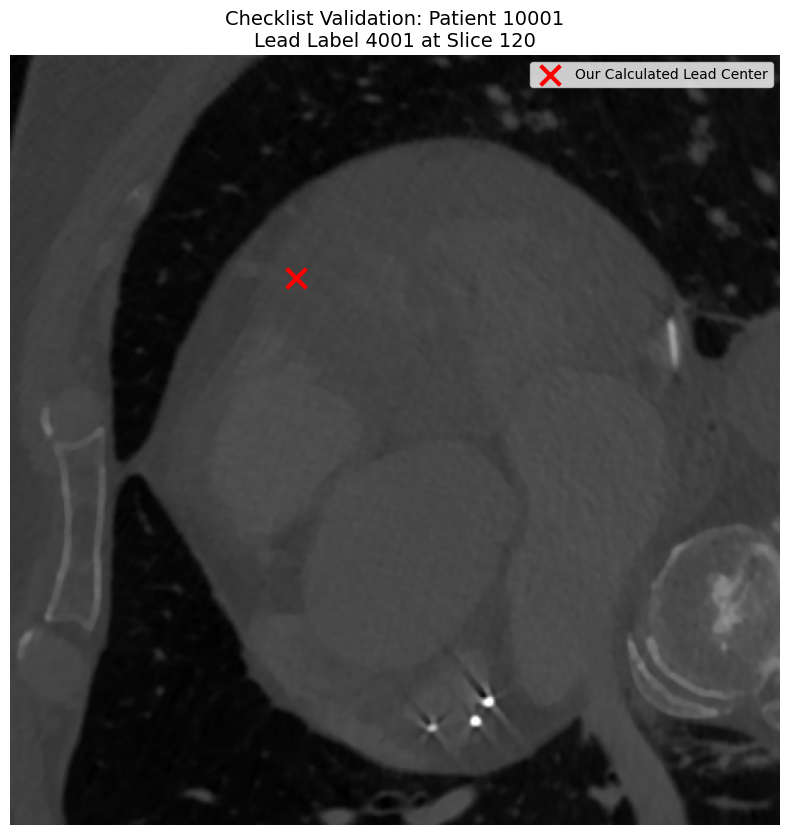

In [57]:
# --- EXECUTION ---
if __name__ == "__main__":
    # You can change the ID to any patient you want to verify
    main(test_patient="10001", run_visuals=True)

In [58]:
print("done")

done
